## Exploring FIFA data

In [ ]:
!pip install kaggle -q
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d stefanoleone992/fifa-21-complete-player-dataset

import zipfile
with zipfile.ZipFile('fifa-21-complete-player-dataset.zip', 'r') as z:
    z.extractall('fifa21_data')


!ls fifa21_data/

Dataset URL: https://www.kaggle.com/datasets/stefanoleone992/fifa-21-complete-player-dataset
License(s): CC0-1.0
100% 83.0M/83.0M [00:01<00:00, 59.5MB/s]

'Career Mode player datasets - FIFA 15-21.xlsx'   players_18.csv
 players_15.csv					  players_19.csv
 players_16.csv					  players_20.csv
 players_17.csv					  players_21.csv


In [ ]:
import pandas as pd
import os

data_path = 'fifa21_data'

files = {
    'players_15.csv': 15,
    'players_16.csv': 16,
    'players_17.csv': 17,
    'players_18.csv': 18,
    'players_19.csv': 19,
    'players_20.csv': 20,
    'players_21.csv': 21,
}

dfs = []
for filename, version in files.items():
    path = os.path.join(data_path, filename)
    if os.path.exists(path):
        temp = pd.read_csv(path, low_memory=False)
        temp['fifa_version'] = version
        dfs.append(temp)
        print(f"FIFA {version}: {len(temp):,} players — {temp.shape[1]} columns")
    else:
        print(f"File not found: {filename}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows after merge: {len(df_all):,}")
print(f"Total columns: {df_all.shape[1]}")

FIFA 15: 16,155 players — 107 columns
FIFA 16: 15,623 players — 107 columns
FIFA 17: 17,597 players — 107 columns
FIFA 18: 17,954 players — 107 columns
FIFA 19: 18,085 players — 107 columns
FIFA 20: 18,483 players — 107 columns
FIFA 21: 18,944 players — 107 columns

Total rows after merge: 122,841
Total columns: 107


In [ ]:
df_latest = (df_all
             .sort_values('fifa_version', ascending=False)
             .drop_duplicates(subset=['sofifa_id'], keep='first')
             .reset_index(drop=True))

print(f"Before: {len(df_all):,} rows")
print(f"After:  {len(df_latest):,} unique players (latest version each)")
print(f"Removed: {len(df_all) - len(df_latest):,} duplicate rows")

# Version distribution of kept rows
print("\nVersion breakdown:")
print(df_latest['fifa_version'].value_counts().sort_index())

Before: 122,841 rows
After:  41,533 unique players (latest version each)
Removed: 81,308 duplicate rows

Version breakdown:
fifa_version
15     3159
16     2885
17     3329
18     3946
19     4062
20     5208
21    18944
Name: count, dtype: int64


In [ ]:
df_latest.to_csv('fifa_latest_per_player.csv', index=False)
print(f"Saved: fifa_latest_per_player.csv")
print(f"Shape: {df_latest.shape[0]:,} rows × {df_latest.shape[1]:,} columns")

df_latest.head(3)

Saved: fifa_latest_per_player.csv
Shape: 41,533 rows × 107 columns


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,fifa_version
0,250978,https://sofifa.com/player/250978/zhen-ma/210002,Ma Zhen,马镇,22,1998-06-01,196,85,China PR,Shanghai Greenland Shenhua FC,...,21+2,21+2,21+2,24+2,24+2,24+2,24+2,24+2,24+2,21
1,257936,https://sofifa.com/player/257936/yue-song/210002,Song Yue,Yue Song,28,1991-11-20,185,79,China PR,Tianjin TEDA FC,...,47+0,47+0,47+0,47+0,47+0,46+1,46+1,46+1,47+0,21
2,257697,https://sofifa.com/player/257697/zitong-chen/2...,Chen Zitong,Zitong Chen,23,1997-02-20,186,80,China PR,Shijiazhuang Ever Bright F.C.,...,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2,21


## Merging FIFA and StatsBomb

In [ ]:
!pip install rapidfuzz
import re
import unicodedata
import numpy as np
import pandas as pd
from rapidfuzz import fuzz
from tqdm.notebook import tqdm
from collections import defaultdict


In [ ]:
metadata = pd.read_csv("interpretable_profiles.csv")
statsbomb_df = pd.read_csv("profiles_scaled.csv")
fifa_df = pd.read_csv("fifa_latest_per_player.csv")

In [ ]:
def norm_nat(val):
    if not isinstance(val, str) or val.strip() == "":
        return ""
    val = unicodedata.normalize("NFD", val)
    val = "".join(c for c in val if unicodedata.category(c) != "Mn")
    return val.lower().strip()

def norm_name(name):
    """Accent-free lowercase — used only for name comparison within same nationality."""
    if not isinstance(name, str):
        return ""
    name = unicodedata.normalize("NFD", name)
    name = "".join(c for c in name if unicodedata.category(c) != "Mn")
    return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", name.lower())).strip()


In [ ]:
# normalise both sides
metadata["_nat_key"] = metadata["nationality"].map(norm_nat)
fifa_df["_nat_key"] = fifa_df["nationality"].map(norm_nat)

# check overlap
sb_nats   = set(metadata["_nat_key"].dropna().unique())
fifa_nats  = set(fifa_df["_nat_key"].dropna().unique())
overlap    = sb_nats & fifa_nats
only_sb    = sb_nats - fifa_nats

print(f"StatsBomb unique nationalities : {len(sb_nats)}")
print(f"FIFA unique nationalities      : {len(fifa_nats)}")
print(f"Overlapping                    : {len(overlap)}")
print(f"Only in StatsBomb (will use fallback): {len(only_sb)}")
if only_sb:
    print(sorted(only_sb)[:20])

StatsBomb unique nationalities : 136
FIFA unique nationalities      : 182
Overlapping                    : 113
Only in StatsBomb (will use fallback): 23
['bhutan', 'bosnia and herzegovina', 'china', 'congo, (kinshasa)', 'congo\xa0(brazzaville)', "cote d'ivoire", 'french guiana', 'guadeloupe', 'guinea-bissau', 'international', 'iran, islamic republic of', 'ireland', 'korea\xa0(south)', 'lao pdr', 'macedonia, republic of', 'martinique', 'monaco', 'nepal', 'tanzania, united republic of', 'trinidad and tobago']


In [ ]:
def match_player(sb_name, nat_key, threshold=72.0):
    """
    1. Look up FIFA players with the same nationality.
    2. Score sb_name against each candidate's long_name and short_name.
    3. Return best match above threshold, or None.
    """
    sb_n = norm_name(sb_name)
    pool = fifa_by_nat.get(nat_key, [])

    # fallback to full FIFA search if pool is empty
    fallback = len(pool) == 0
    if fallback:
        pool = [entry for bucket in fifa_by_nat.values() for entry in bucket]

    best_score, best_row = -1, None
    for entry in pool:
        s = max(fuzz.WRatio(sb_n, entry["long_norm"]),
                fuzz.WRatio(sb_n, entry["short_norm"]))
        if s > best_score:
            best_score, best_row = s, entry["row"]

    if best_score >= threshold:
        result = best_row.to_dict()
        result["_match_score"]    = round(best_score, 2)
        result["_used_fallback"]  = fallback
        return result
    return None

test = match_player("Lionel Andrés Messi", "argentina")
print(test.get("long_name"), test.get("_match_score") if test else "no match")

Lionel Andrés Messi Cuccittini 90.0


In [ ]:
THRESHOLD = 72.0

fifa_cols = [c for c in fifa_df.columns if c != "_nat_key"]
rows = []

for _, player_row in tqdm(metadata.iterrows(),
                          total=len(metadata),
                          desc="Matching players"):
    sb_name  = str(player_row.get("player",   "") or "")
    nat_key  = str(player_row.get("_nat_key", "") or "")
    match    = match_player(sb_name, nat_key, threshold=THRESHOLD)

    entry = player_row.to_dict()
    if match:
        for fc in fifa_cols:
            entry[f"fifa_{fc}"] = match.get(fc, np.nan)
        entry["_match_score"]    = match["_match_score"]
        entry["_used_fallback"]  = match["_used_fallback"]
        entry["_match_status"]   = "matched"
    else:
        for fc in fifa_cols:
            entry[f"fifa_{fc}"] = np.nan
        entry["_match_score"]    = 0.0
        entry["_used_fallback"]  = False
        entry["_match_status"]   = "unmatched"

    rows.append(entry)

matched_df = pd.DataFrame(rows)
print(f"Done — {len(matched_df):,} rows")

Matching players:   0%|          | 0/7744 [00:00<?, ?it/s]

Done — 7,744 rows


In [ ]:
# ── Validate row alignment ────────────────────────────────────────────────
assert len(metadata) == len(statsbomb_df), (
    f"Row count mismatch: interpretable_profiles={len(metadata)}, "
    f"df_model={len(statsbomb_df)}"
)
assert len(matched_df) == len(statsbomb_df), (
    f"Row count mismatch: matched_df={len(matched_df)}, "
    f"df_model={len(statsbomb_df)}"
)

In [ ]:
# Merge all three datasets
# matched_df  = metadata + FIFA columns
# df_model    = scaled StatsBomb features (row-aligned with matched_df)
scaled = statsbomb_df.add_prefix("scaled_").reset_index(drop=True)

unified = pd.concat(
    [
        matched_df.reset_index(drop=True),   # Dataset 1 (SB metadata) + Dataset 2 (FIFA)
        scaled,                               # Dataset 3 (scaled SB features)
    ],
    axis=1
)

# Drop internal helper columns
unified.drop(columns=["_nat_key"], errors="ignore", inplace=True)


In [ ]:
n_matched   = (unified["_match_status"] == "matched").sum()
n_unmatched = (unified["_match_status"] == "unmatched").sum()
n_fallback  = unified["_used_fallback"].sum()
scores      = unified.loc[unified["_match_status"] == "matched", "_match_score"]

print(f"Total players    : {len(unified):,}")
print(f"Matched          : {n_matched:,}  ({n_matched/len(unified)*100:.1f}%)")
print(f"Unmatched        : {n_unmatched:,}  ({n_unmatched/len(unified)*100:.1f}%)")
print(f"Used fallback    : {n_fallback:,}  (no nationality match — searched all FIFA)")
print(f"Score range      : {scores.min():.1f} – {scores.max():.1f}  (median {scores.median():.1f})")
print(f"Final shape      : {unified.shape}")

Total players    : 7,744
Matched          : 6,728  (86.9%)
Unmatched        : 1,016  (13.1%)
Used fallback    : 619  (no nationality match — searched all FIFA)
Score range      : 72.0 – 100.0  (median 100.0)
Final shape      : (7744, 285)


In [ ]:
# Column group check
sb_cols     = [c for c in unified.columns if not c.startswith("fifa_") and not c.startswith("scaled_")]
fifa_cols_  = [c for c in unified.columns if c.startswith("fifa_")]
scaled_cols = [c for c in unified.columns if c.startswith("scaled_")]

print(f"\nColumn breakdown:")
print(f"  StatsBomb metadata + features : {len(sb_cols)}")
print(f"  FIFA columns (fifa_*)         : {len(fifa_cols_)}")
print(f"  Scaled SB features (scaled_*) : {len(scaled_cols)}")


Column breakdown:
  StatsBomb metadata + features : 95
  FIFA columns (fifa_*)         : 107
  Scaled SB features (scaled_*) : 83


In [ ]:
unified.head(2)

,player_id,player,team,position,position_group,nationality,total_minutes,matches_played,avg_minutes_per_match,pass_completion,...,scaled_cross_quality_index,scaled_shot_quality_index,scaled_block_quality_index,scaled_pass_creativity_index,scaled_set_piece_delivery_index,scaled_dribble_composite,scaled_duel_composite,scaled_discipline_score,scaled_pos_FWD,scaled_pos_MID
0,2935.0,Nordi Mukiele Mulere,Paris Saint-Germain,Right Center Back,DEF,France,1262,15,84.133333,0.882967,...,0.370858,0.015105,0.000000,-0.256110,0.280912,-0.286054,-0.065008,-0.319777,0,0
1,2936.0,Christophe Kerbrat,Guingamp,Right Center Back,DEF,France,2578,29,88.896552,0.768327,...,0.290472,-0.305814,0.967804,-0.201232,0.526049,-0.430178,0.851557,-0.224854,0,0


In [ ]:
unified.to_parquet("unified_player_dataset.parquet", index=False)

## Models

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_parquet("unified_player_dataset.parquet")

In [ ]:
# Only matched players have FIFA targets
df = unified[unified["_match_status"].isin(["matched", "manual"])].copy()
df = df.reset_index(drop=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6728 entries, 0 to 6727
Columns: 285 entries, player_id to scaled_pos_MID
dtypes: bool(1), float64(228), int64(6), object(50)
memory usage: 14.6+ MB


In [ ]:
TARGET_OVERALL = "fifa_overall"
TARGET_VALUE   = "fifa_value_eur"

# training is done in the scaled statsbomb data
# crossbonding to their matching in fifa data with the value and rate is targets
feature_cols = [c for c in df.columns if c.startswith("scaled_")]

df_overall = df.dropna(subset=[TARGET_OVERALL] + feature_cols).copy()
df_value   = df.dropna(subset=[TARGET_VALUE]   + feature_cols).copy()
df_value   = df_value[df_value[TARGET_VALUE] > 0].copy()

# Log-transform value
df_value["log_value"] = np.log1p(df_value[TARGET_VALUE])

In [ ]:
print(f"Matched players total: {len(df):,}")
print(f"Available for overall model: {len(df_overall):,}")
print(f"Available for value model: {len(df_value):,}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Overall range: {df_overall[TARGET_OVERALL].min():.0f} – {df_overall[TARGET_OVERALL].max():.0f}")
print(f"Value range: €{df_value[TARGET_VALUE].min():,.0f} – €{df_value[TARGET_VALUE].max():,.0f}")

Matched players total: 6,728
Available for overall model: 6,728
Available for value model: 6,499
Feature columns: 83
Overall range: 46 – 93
Value range: €1,000 – €105,500,000


In [ ]:
MODEL_PARAMS = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 4,
    min_samples_leaf  = 10,
    subsample         = 0.8,
    random_state      = 42,
)

def train_and_evaluate(X, y, label):
    """Train GBR, cross-validate, return (model, cv_scores)."""
    model = GradientBoostingRegressor(**MODEL_PARAMS)

    cv    = KFold(n_splits=5, shuffle=True, random_state=42)
    r2s   = cross_val_score(model, X, y, cv=cv, scoring="r2")
    maes  = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    model.fit(X, y)
    y_pred = model.predict(X)

    print(f"{label}")
    print(f"CV R²: {r2s.mean():.3f} ± {r2s.std():.3f}")
    print(f"CV MAE: {(-maes).mean():.3f} ± {(-maes).std():.3f}")
    print(f"Train R²: {r2_score(y, y_pred):.3f}")
    print(f"Train MAE: {mean_absolute_error(y, y_pred):.3f}")
    return model

In [ ]:
X_overall = df_overall[feature_cols].values
y_overall = df_overall[TARGET_OVERALL].values

model_overall = train_and_evaluate(X_overall, y_overall, "FIFA Overall Rating")

FIFA Overall Rating
CV R²: 0.207 ± 0.037
CV MAE: 5.203 ± 0.047
Train R²: 0.627
Train MAE: 3.571


In [ ]:
X_value = df_value[feature_cols].values
y_value = df_value["log_value"].values

model_value = train_and_evaluate(X_value, y_value, "FIFA Market Value (log €)")

FIFA Market Value (log €)
CV R²: 0.188 ± 0.030
CV MAE: 1.114 ± 0.012
Train R²: 0.626
Train MAE: 0.752


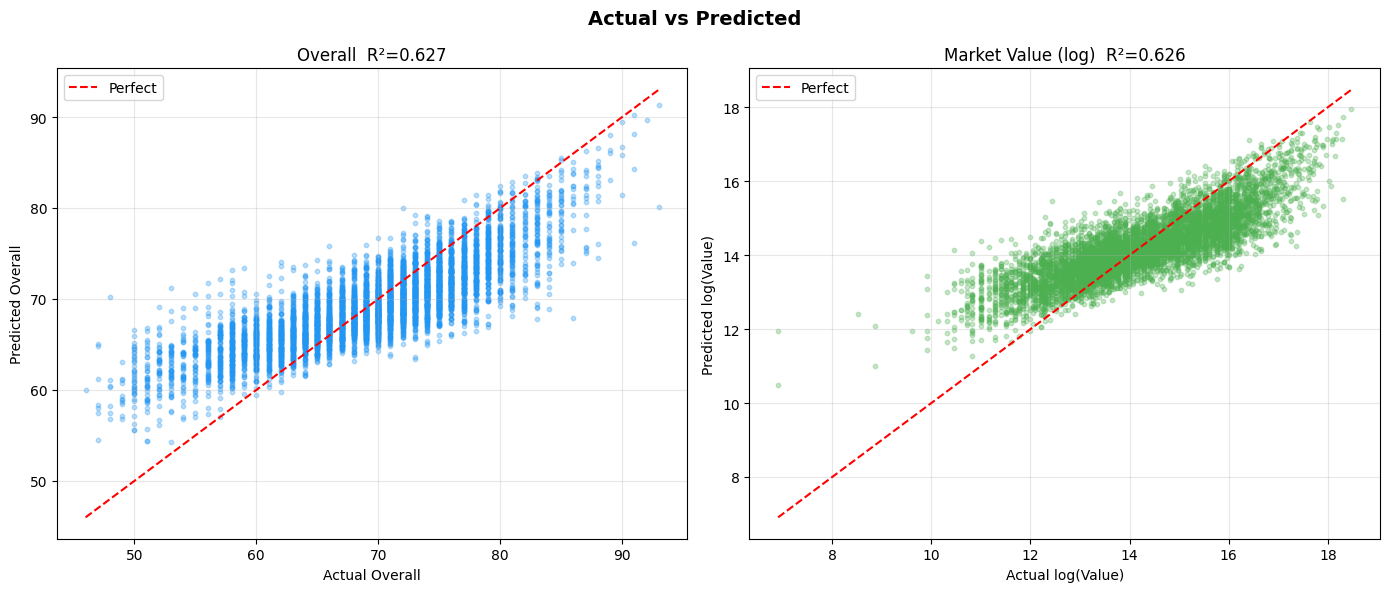

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted", fontsize=14, fontweight="bold")

# overall
y_pred_overall = model_overall.predict(X_overall)
axes[0].scatter(y_overall, y_pred_overall, alpha=0.3, s=10, color="#2196F3")
lims = [y_overall.min(), y_overall.max()]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect")
axes[0].set_xlabel("Actual Overall"); axes[0].set_ylabel("Predicted Overall")
axes[0].set_title(f"Overall  R²={r2_score(y_overall, y_pred_overall):.3f}")
axes[0].legend(); axes[0].grid(alpha=0.3)

# value (in log space)
y_pred_logval = model_value.predict(X_value)
axes[1].scatter(y_value, y_pred_logval, alpha=0.3, s=10, color="#4CAF50")
lims = [y_value.min(), y_value.max()]
axes[1].plot(lims, lims, "r--", lw=1.5, label="Perfect")
axes[1].set_xlabel("Actual log(Value)"); axes[1].set_ylabel("Predicted log(Value)")
axes[1].set_title(f"Market Value (log)  R²={r2_score(y_value, y_pred_logval):.3f}")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_overall = df_overall.copy()
df_overall["predicted_overall"]  = model_overall.predict(X_overall)
df_overall["gap_overall"]        = df_overall["predicted_overall"] - df_overall[TARGET_OVERALL]

df_value = df_value.copy()
df_value["predicted_log_value"]  = model_value.predict(X_value)
df_value["predicted_value_eur"]  = np.expm1(df_value["predicted_log_value"])
df_value["gap_value_eur"]        = df_value["predicted_value_eur"] - df_value[TARGET_VALUE]
df_value["gap_value_pct"]        = (df_value["gap_value_eur"] / df_value[TARGET_VALUE]) * 100

DISPLAY_COLS_OVERALL = [
    "player", "team", "position", "nationality",
    TARGET_OVERALL, "predicted_overall", "gap_overall",
    "total_minutes", "matches_played",
]
DISPLAY_COLS_VALUE = [
    "player", "team", "position", "nationality",
    TARGET_VALUE, "predicted_value_eur", "gap_value_eur", "gap_value_pct",
    "total_minutes", "matches_played",
]

for df_, cols in [(df_overall, DISPLAY_COLS_OVERALL), (df_value, DISPLAY_COLS_VALUE)]:
    if "fifa_age" in df_.columns:
        cols.insert(4, "fifa_age")

print(f"Gap analysis ready")
print(f"  Overall — mean gap: {df_overall['gap_overall'].mean():.2f}  std: {df_overall['gap_overall'].std():.2f}")
print(f"  Value   — mean gap: €{df_value['gap_value_eur'].mean():,.0f}")

Gap analysis ready
  Overall — mean gap: -0.00  std: 4.56
  Value   — mean gap: €-1,957,344


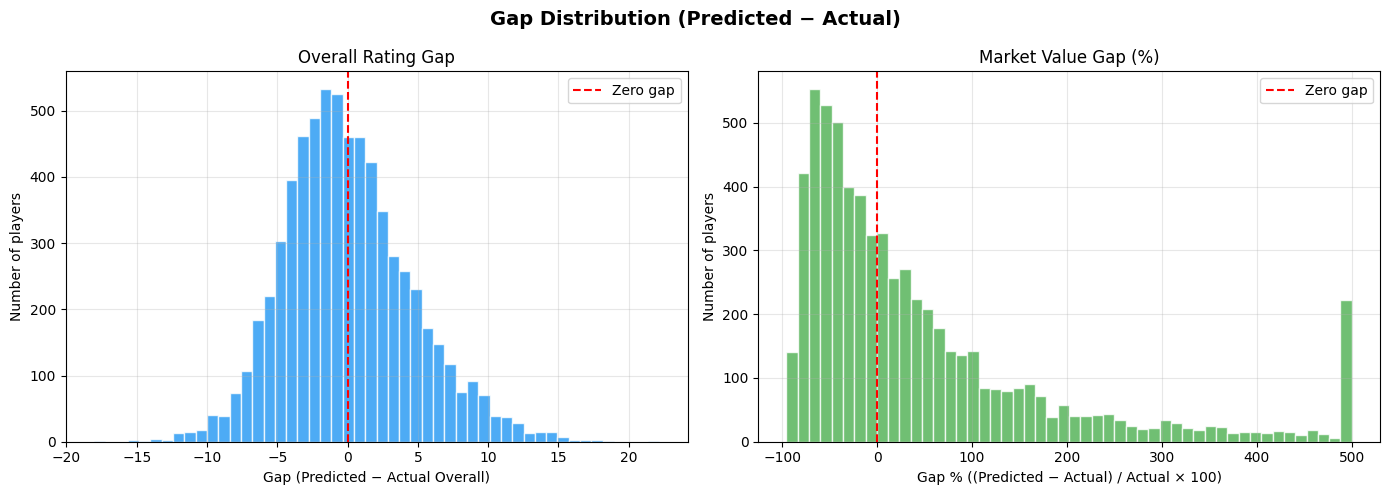

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Gap Distribution (Predicted − Actual)", fontsize=14, fontweight="bold")

axes[0].hist(df_overall["gap_overall"], bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", lw=1.5, label="Zero gap")
axes[0].set_xlabel("Gap (Predicted − Actual Overall)")
axes[0].set_ylabel("Number of players")
axes[0].set_title("Overall Rating Gap")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(df_value["gap_value_pct"].clip(-200, 500), bins=50,
             color="#4CAF50", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", lw=1.5, label="Zero gap")
axes[1].set_xlabel("Gap % ((Predicted − Actual) / Actual × 100)")
axes[1].set_ylabel("Number of players")
axes[1].set_title("Market Value Gap (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gap_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
N = 5
MIN_MINUTES = 270

def scouting_table(df_, gap_col, display_cols, label, ascending=False):
    out = (df_[df_["total_minutes"] >= MIN_MINUTES]
           .sort_values(gap_col, ascending=ascending)
           [display_cols]
           .head(N)
           .reset_index(drop=True))

    out.index += 1

    color_map = "Greens" if "UNDERRATED" in label else "Reds_r"

    styled_out = (out.style
                  .background_gradient(subset=[gap_col], cmap=color_map)
                  .format({gap_col: "{:+.2f}"})
                  .set_caption(f"<b>{label}</b> (min {MIN_MINUTES} mins)")
                  .set_table_styles([
                      {'selector': 'caption', 'props': [('color', 'white'), ('font-size', '16px'),
                                                        ('background-color', '#333'), ('text-align', 'center'),
                                                        ('padding', '5px')]}
                  ]))
    return styled_out

In [ ]:
under_overall = scouting_table(df_overall, "gap_overall", DISPLAY_COLS_OVERALL,
                               f"TOP {N} UNDERRATED — Overall Rating")
display(under_overall)

,player,team,position,nationality,fifa_age,fifa_overall,predicted_overall,gap_overall,total_minutes,matches_played
1,Jack Frank Porteous Cork,Swansea City,Right Center Midfield,England,18.000000,48.000000,70.176401,+22.18,3034,35
2,Ezequiel Muñoz,Genoa,Right Center Back,Argentina,21.000000,53.000000,71.159492,+18.16,1581,19
3,Carl Gerard McHugh,ATK Mohun Bagan,Left Defensive Midfield,Ireland,19.000000,47.000000,65.035060,+18.04,1378,18
4,Kevin Duvan Castaño Gil,Colombia,Right Center Midfield,Colombia,24.000000,47.000000,64.828028,+17.83,360,4
5,Sulzeer Jeremiah ''Sol' Campbell,Arsenal,Left Center Back,England,17.000000,52.000000,69.129213,+17.13,3068,35


In [ ]:
over_overall  = scouting_table(df_overall, "gap_overall", DISPLAY_COLS_OVERALL,
                               f"TOP {N} OVERRATED — Overall Rating", ascending=True)
display(over_overall)

,player,team,position,nationality,fifa_age,fifa_overall,predicted_overall,gap_overall,total_minutes,matches_played
1,Brianna Visalli,West Ham United LFC,Left Center Midfield,United States of America,33.000000,83.000000,67.825548,-15.17,2446,29
2,Jonas Gonçalves Oliveira,Valencia,Center Attacking Midfield,Brazil,34.000000,84.000000,68.905350,-15.09,540,6
3,Ludmila da Silva,Brazil Women's,Right Midfield,Brazil,28.000000,91.000000,76.169218,-14.83,333,4
4,Joe Gomez,Liverpool,Left Back,England,23.000000,83.000000,68.960385,-14.04,528,6
5,Megan Montefusco,OL Reign,Right Center Back,United States of America,28.000000,84.000000,70.538848,-13.46,540,6


In [ ]:
def scouting_table(df_, gap_col, display_cols, label, ascending=False):
    out = (df_[df_["total_minutes"] >= MIN_MINUTES]
           .sort_values(gap_col, ascending=ascending)
           [display_cols]
           .head(N)
           .reset_index(drop=True))
    out.index += 1

    color_map = "Greens" if "UNDERRATED" in label else "Reds_r"

    format_dict = {}
    if "gap_overall" in out.columns:
        format_dict["gap_overall"] = "{:+.2f}"
    if "gap_value_pct" in out.columns:
        format_dict["gap_value_pct"] = "{:+.1f}%"

    eur_cols = ["fifa_value_eur", "predicted_value_eur", "gap_value_eur", "value_eur"]
    for col in eur_cols:
        if col in out.columns:
            format_dict[col] = "€{:,.0f}"

    styled = (out.style
              .background_gradient(subset=[gap_col], cmap=color_map)
              .format(format_dict)
              .set_caption(f"<b>{label}</b> (min {MIN_MINUTES} mins)")
              .set_table_styles([
                  {'selector': 'caption', 'props': [
                      ('color', 'white'),
                      ('font-size', '15px'),
                      ('background-color', '#2c3e50'),
                      ('text-align', 'left'),
                      ('padding', '8px')]}
              ]))

    return styled

In [ ]:
under_value = scouting_table(df_value, "gap_value_eur", DISPLAY_COLS_VALUE,
                             f"TOP {N} UNDERRATED — Market Value")

display(under_value)


,player,team,position,nationality,fifa_age,fifa_value_eur,predicted_value_eur,gap_value_eur,gap_value_pct,total_minutes,matches_played
1,Diego da Silva Costa,Chelsea,Center Forward,Spain,31.000000,"€13,500,000","€27,147,650","€13,647,650",+101.1%,3707,46
2,Thiago Motta,Paris Saint-Germain,Center Defensive Midfield,Italy,34.000000,"€5,500,000","€13,423,938","€7,923,938",+144.1%,4035,48
3,Clément Lenglet,Barcelona,Left Center Back,France,23.000000,"€3,900,000","€11,480,467","€7,580,467",+194.4%,6830,80
4,Ivan Rakitić,Barcelona,Right Center Midfield,Croatia,32.000000,"€17,000,000","€24,050,419","€7,050,419",+41.5%,17599,208
5,Pedro González López,Barcelona,Left Center Midfield,Spain,17.000000,"€6,000,000","€12,481,749","€6,481,749",+108.0%,3843,49


In [ ]:
over_value  = scouting_table(df_value, "gap_value_eur", DISPLAY_COLS_VALUE,
                             f"TOP {N} OVERRATED — Market Value", ascending=True)
display(over_value)

,player,team,position,nationality,fifa_age,fifa_value_eur,predicted_value_eur,gap_value_eur,gap_value_pct,total_minutes,matches_played
1,Ludmila da Silva,Brazil Women's,Right Midfield,Brazil,28.000000,"€90,000,000","€5,527,969","€-84,472,031",-93.9%,333,4
2,Jadon Sancho,England,Right Wing,England,20.000000,"€69,500,000","€7,707,680","€-61,792,320",-88.9%,338,4
3,Kevin De Bruyne,Manchester City,Right Wing,Belgium,29.000000,"€87,000,000","€28,045,400","€-58,954,600",-67.8%,3809,44
4,Virgil van Dijk,Southampton,Left Center Back,Netherlands,28.000000,"€75,500,000","€17,516,116","€-57,983,884",-76.8%,4227,47
5,Trent Alexander-Arnold,England,Right Back,England,21.000000,"€60,000,000","€4,524,106","€-55,475,894",-92.5%,651,8


## Clustring

In [ ]:
FIFA_IDENTITY_COLS = {
    "fifa_sofifa_id", "fifa_player_url", "fifa_short_name", "fifa_long_name",
    "fifa_age", "fifa_dob", "fifa_nationality", "fifa_club_name",
    "fifa_league_name", "fifa_player_url", "fifa_player_tags",
    "fifa_player_traits", "fifa_work_rate", "fifa_body_type",
    "fifa_real_face", "fifa_loaned_from", "fifa_joined",
    "fifa_contract_valid_until", "fifa_nation_position",
    "fifa_nation_jersey_number", "fifa_team_position",
    "fifa_team_jersey_number", "fifa_preferred_foot",
    "fifa_player_positions", "fifa_clean_name", "fifa_fifa_version",
    # target
    "fifa_overall", "fifa_potential",
    # position-specific overall ratings
    "fifa_ls", "fifa_st", "fifa_rs", "fifa_lw", "fifa_lf", "fifa_cf",
    "fifa_rf", "fifa_rw", "fifa_lam", "fifa_cam", "fifa_ram", "fifa_lm",
    "fifa_lcm", "fifa_cm", "fifa_rcm", "fifa_rm", "fifa_lwb", "fifa_ldm",
    "fifa_cdm", "fifa_rdm", "fifa_rwb", "fifa_lb", "fifa_lcb", "fifa_cb",
    "fifa_rcb", "fifa_rb",
}

In [ ]:
# Numeric FIFA attributes that ARE valid features
FIFA_ATTR_COLS = [
    c for c in df.columns
    if c.startswith("fifa_")
    and c not in FIFA_IDENTITY_COLS
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

print(f"FIFA attribute features: {len(FIFA_ATTR_COLS)}")


FIFA attribute features: 55


In [ ]:
feature_cols = [
    c for c in df.columns
    if isinstance(df[c], pd.Series)          # guard against duplicate col
    and c not in (
        ["player", "player_id", "team", "position", "position_group",
         "nationality", "birth_date", "matches_played", "total_minutes",
         "avg_minutes_per_match", "_match_score", "_match_status",
         "_used_fallback", "_nat_key"]
        + [c for c in df.columns if c.startswith("scaled_")]
        + [c for c in df.columns if c.startswith("career_")]
    )
    and c not in FIFA_IDENTITY_COLS
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

pos_dummy_cols = [c for c in df.columns if c.startswith("pos_")]

feature_cols = feature_cols + pos_dummy_cols
print(f"Total features: {len(feature_cols)}")

Total features: 140


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

MODEL_PARAMS = dict(
    max_iter        = 300,
    learning_rate   = 0.05,
    max_depth       = 4,
    min_samples_leaf= 20,
    max_features    = 0.7,
    random_state    = 42,
)

def train_and_evaluate(X, y, label):
    model = HistGradientBoostingRegressor(**MODEL_PARAMS)
    cv    = KFold(n_splits=5, shuffle=True, random_state=42)
    r2s   = cross_val_score(model, X, y, cv=cv, scoring="r2")
    maes  = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    model.fit(X, y)
    y_pred = model.predict(X)
    print(f"{label}")
    print(f"CV R²: {r2s.mean():.3f} ± {r2s.std():.3f}")
    print(f"CV MAE: {(-maes).mean():.3f} ± {(-maes).std():.3f}")
    print(f"Train R² : {r2_score(y, y_pred):.3f}")
    print(f"Train MAE: {mean_absolute_error(y, y_pred):.3f}")
    gap = r2_score(y, y_pred) - r2s.mean()
    print(f"Overfit gap: {gap:.3f}  {'high' if gap > 0.15 else 'ok'}")
    return model

In [ ]:
X_overall = df_overall[feature_cols].values
y_overall = df_overall[TARGET_OVERALL].values

model_overall = train_and_evaluate(X_overall, y_overall, "FIFA Overall Rating")

FIFA Overall Rating
CV R²: 0.981 ± 0.001
CV MAE: 0.768 ± 0.017
Train R² : 0.990
Train MAE: 0.584
Overfit gap: 0.009  ok


In [128]:
# What position labels do we have and how many of each?
print("position_group:\n", df["position_group"].value_counts())
print("\nposition (detailed):\n", df["position"].value_counts().head(30))

position_group:
 position_group
DEF    2531
FWD    2377
MID    1820
Name: count, dtype: int64

position (detailed):
 position
Center Forward               656
Left Center Back             579
Left Back                    557
Right Center Back            552
Right Back                   542
Center Attacking Midfield    414
Left Center Midfield         392
Left Wing                    386
Right Wing                   326
Left Defensive Midfield      311
Center Defensive Midfield    305
Right Center Midfield        290
Right Defensive Midfield     252
Left Midfield                251
Left Center Forward          220
Right Midfield               193
Right Center Forward         181
Left Wing Back                94
Right Wing Back               92
Center Back                   83
Left Attacking Midfield       28
Right Attacking Midfield      19
Center Midfield                4
Substitute                     1
Name: count, dtype: int64


In [151]:
# Only use StatsBomb-derived rate stats
CLASSIFIER_FEATURES = [
    "xg_per_90",
    "avg_xg_per_shot",
    "xg_overperformance",
    "dribble_success_rate",
    "carry_box_ratio",
    "chance_creation_rate",
    "progressive_pass_ratio",
    "progressive_carry_ratio",
    "avg_pass_length",
    "long_ball_ratio",
    "duel_win_rate",
    "turnover_rate",
    "cross_ratio",
    "avg_carry_dist",
    "avg_shot_distance",
]

# Minimum minutes filter
df_clf = df[df["total_minutes"] >= 450].copy()
df_clf = df_clf.dropna(subset=CLASSIFIER_FEATURES + ["position_group"])

print(f"Samples: {len(df_clf)}")
print(df_clf["position_group"].value_counts())

Samples: 3272
position_group
DEF    1245
FWD    1139
MID     888
Name: count, dtype: int64


In [169]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X = df_clf[CLASSIFIER_FEATURES].values
le = LabelEncoder()
y = le.fit_transform(df_clf["position_group"])

# Stratified CV — important with imbalanced position counts
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_clf = RandomForestClassifier(
    n_estimators    = 700,
    min_samples_split = 2,
    max_depth       = 20,
    min_samples_leaf= 4,
    max_features    = "log2",
    class_weight    = "balanced",
    bootstrap       = True,
    random_state    = 42,
    n_jobs          = -1,
)

scores = cross_val_score(model_clf, X, y, cv=cv, scoring="accuracy")
print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

# Full fit for predictions
model_clf.fit(X, y)
y_pred = model_clf.predict(X)
y_prob = model_clf.predict_proba(X)

print("\n", classification_report(y, y_pred, target_names=le.classes_))

CV Accuracy: 0.866 ± 0.014

               precision    recall  f1-score   support

         DEF       0.98      0.97      0.98      1245
         FWD       0.96      0.97      0.96      1139
         MID       0.94      0.95      0.95       888

    accuracy                           0.96      3272
   macro avg       0.96      0.96      0.96      3272
weighted avg       0.96      0.96      0.96      3272



In [170]:
df_clf["predicted_position"] = le.inverse_transform(y_pred)
df_clf["prediction_confidence"] = y_prob.max(axis=1)

# Predicted probabilities for each position
for i, cls in enumerate(le.classes_):
    df_clf[f"prob_{cls}"] = y_prob[:, i]

# Misclassified = model disagrees with FIFA label
df_clf["misclassified"] = (
    df_clf["position_group"] != df_clf["predicted_position"]
)

# High-confidence misclassifications are the interesting ones
# Low confidence = genuinely hybrid player
# High confidence wrong = FIFA has them in the wrong box
mismatch = df_clf[df_clf["misclassified"]]\
    .sort_values("prediction_confidence", ascending=False)

print(f"\nTotal misclassified: {df_clf['misclassified'].sum()} "
      f"({df_clf['misclassified'].mean():.1%} of players)\n")

print("High-confidence misclassifications (top 20)")
print(mismatch[[
    "player", "position", "position_group",
    "predicted_position", "prediction_confidence",
    "total_minutes", "fifa_overall"
]].head(10).to_string(index=False))


Total misclassified: 117 (3.6% of players)

High-confidence misclassifications (top 20)
                      player                  position position_group predicted_position  prediction_confidence  total_minutes  fifa_overall
                Nathan Tella           Right Wing Back            DEF                FWD               0.795848           2034          61.0
            Jeremie Frimpong           Right Wing Back            DEF                FWD               0.779750           2793          70.0
         Pablo Fornals Malla   Left Defensive Midfield            FWD                MID               0.718940           2582          79.0
               Thomas Müller Center Attacking Midfield            MID                FWD               0.711821           4021          86.0
João Paulo Moreira Fernandes                 Left Back            DEF                MID               0.704222            450          64.0
                 Yunus Mallı Center Attacking Midfield           

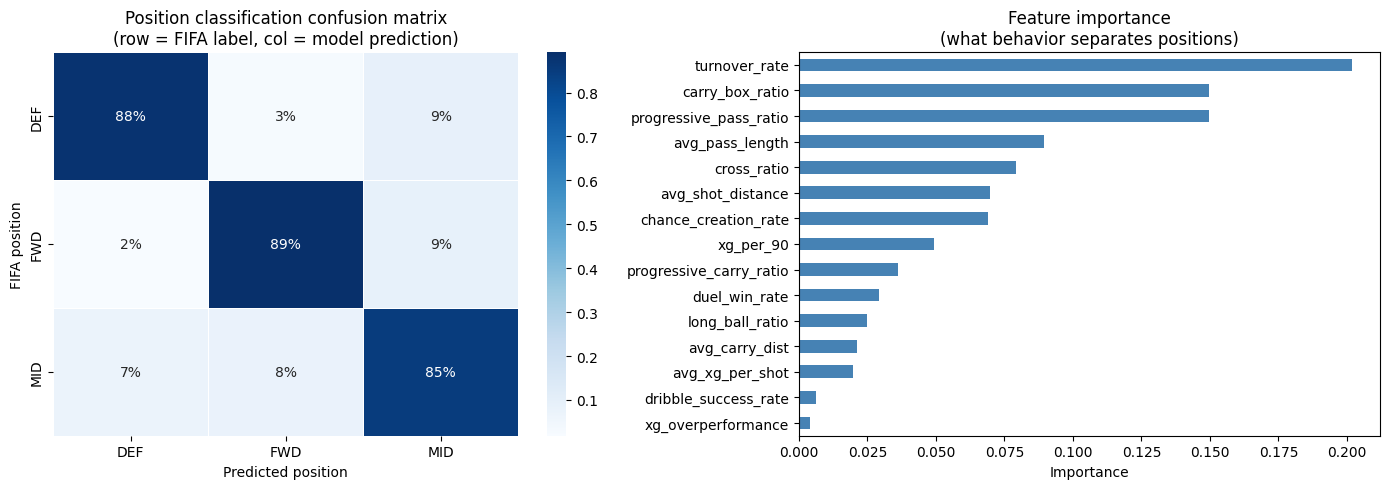

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

sns.heatmap(
    cm_pct, annot=True, fmt=".0%",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues", ax=axes[0],
    linewidths=0.5
)
axes[0].set_xlabel("Predicted position")
axes[0].set_ylabel("FIFA position")
axes[0].set_title("Position classification confusion matrix\n(row = FIFA label, col = model prediction)")

# Feature importances
feat_imp = pd.Series(
    model_clf.feature_importances_,
    index=CLASSIFIER_FEATURES
).sort_values(ascending=True)

feat_imp.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_title("Feature importance\n(what behavior separates positions)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("position_classifier.png", dpi=150, bbox_inches="tight")
plt.show()

In [158]:
ROLE_MAP = {

    # Fullbacks
    "Left Back":           "Fullback",
    "Right Back":          "Fullback",
    "Left Wing Back":      "Fullback",
    "Right Wing Back":     "Fullback",

    # Center backs
    "Center Back":         "Center Back",
    "Left Center Back":    "Center Back",
    "Right Center Back":   "Center Back",

    # Defensive / holding mids
    "Left Defensive Midfield":  "Defensive Mid",
    "Center Defensive Midfield":"Defensive Mid",
    "Right Defensive Midfield": "Defensive Mid",

    # Box-to-box / central mids
    "Left Center Midfield":  "Central Mid",
    "Right Center Midfield": "Central Mid",
    "Center Midfield":       "Central Mid",
    "Left Midfield":         "Central Mid",
    "Right Midfield":        "Central Mid",

    # Attacking mids / CAM
    "Center Attacking Midfield": "Attacking Mid",
    "Left Attacking Midfield":   "Attacking Mid",
    "Right Attacking Midfield":  "Attacking Mid",

    # Wingers
    "Left Wing":  "Winger",
    "Right Wing": "Winger",

    # strikers
    "Center Forward":       "Striker",
    "Left Center Forward":  "Striker",
    "Right Center Forward": "Striker",

    # Drop
    "Substitute": None,
}

df_clf = df[df["total_minutes"] >= 450].copy()
df_clf["role"] = df_clf["position"].map(ROLE_MAP)
df_clf = df_clf[df_clf["role"].notna()]

print(df_clf["role"].value_counts())
print(f"\nTotal: {len(df_clf)} players")

role
Fullback         642
Center Back      611
Striker          493
Central Mid      485
Defensive Mid    418
Winger           417
Attacking Mid    206
Name: count, dtype: int64

Total: 3272 players


In [167]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

X = df_clf[CLASSIFIER_FEATURES].values
le = LabelEncoder()
y = le.fit_transform(df_clf["role"])

# Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_clf = RandomForestClassifier(
    n_estimators    = 700,
    min_samples_split = 2,
    max_depth       = 20,
    min_samples_leaf= 4,
    max_features    = "log2",
    class_weight    = "balanced",
    bootstrap       = True,
    random_state    = 42,
    n_jobs          = -1,
)

scores = cross_val_score(model_clf, X, y, cv=cv, scoring="accuracy")
print(f"CV Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

model_clf.fit(X, y)
y_pred = model_clf.predict(X)
y_prob = model_clf.predict_proba(X)

print("\n", classification_report(y, y_pred, target_names=le.classes_))

CV Accuracy: 0.704 ± 0.016

                precision    recall  f1-score   support

Attacking Mid       0.93      0.96      0.95       206
  Center Back       0.97      0.96      0.97       611
  Central Mid       0.93      0.82      0.87       485
Defensive Mid       0.89      0.95      0.92       418
     Fullback       0.95      0.94      0.94       642
      Striker       0.94      0.95      0.94       493
       Winger       0.86      0.92      0.89       417

     accuracy                           0.93      3272
    macro avg       0.92      0.93      0.93      3272
 weighted avg       0.93      0.93      0.93      3272



In [168]:
df_clf["predicted_role"] = le.inverse_transform(y_pred)
df_clf["prediction_confidence"] = y_prob.max(axis=1)

for i, cls in enumerate(le.classes_):
    df_clf[f"prob_{cls}"] = y_prob[:, i]

df_clf["misclassified"] = (
    df_clf["role"] != df_clf["predicted_role"]
)

mismatch = df_clf[df_clf["misclassified"]]\
    .sort_values("prediction_confidence", ascending=False)

print(f"\nTotal misclassified: {df_clf['misclassified'].sum()} "
      f"({df_clf['misclassified'].mean():.1%} of players)\n")

print("High-confidence misclassifications (top 20)")
print(mismatch[[
    "player", "position", "role",           # role = FIFA's 7-class label
    "predicted_role",                        # model's behavioral prediction
    "prediction_confidence",
    "total_minutes", "fifa_overall"
]].head(10).to_string(index=False))


Total misclassified: 238 (7.3% of players)

High-confidence misclassifications (top 20)
               player             position        role predicted_role  prediction_confidence  total_minutes  fifa_overall
      Luca Rossettini           Right Back    Fullback    Center Back               0.739919           2584          71.0
          Emil Krafth           Right Back    Fullback    Center Back               0.687634            846          74.0
Carlos Marchena López Left Center Midfield Central Mid    Center Back               0.662507            791          66.0
 David García Santana           Right Back    Fullback    Center Back               0.662436           1760          72.0
        Gaëtan Perrin           Right Wing      Winger        Striker               0.647523            450          65.0
Aldo Kalulu Kyatengwa            Left Wing      Winger        Striker               0.630514            888          68.0
      Moritz Hartmann           Right Wing      Winger   

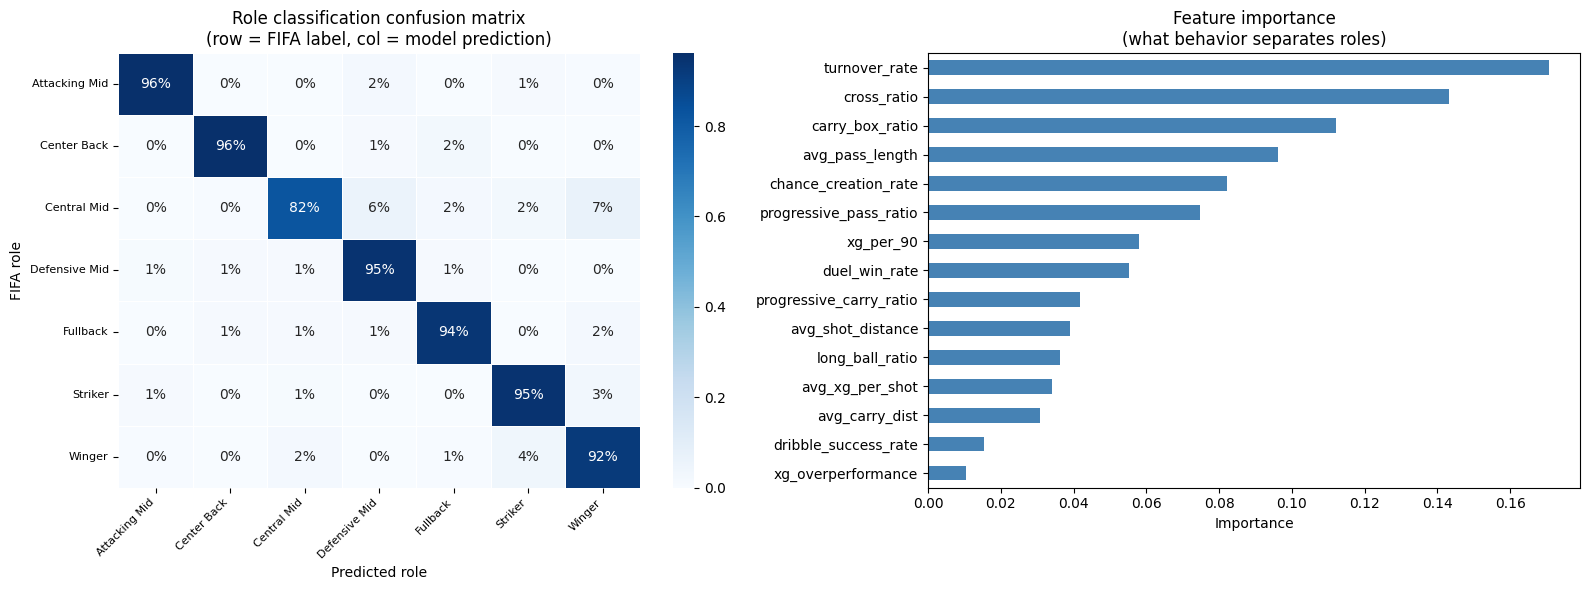

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm     = confusion_matrix(y, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_pct, annot=True, fmt=".0%",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues", ax=axes[0],
    linewidths=0.5
)
axes[0].set_xlabel("Predicted role")
axes[0].set_ylabel("FIFA role")
axes[0].set_title(
    "Role classification confusion matrix\n(row = FIFA label, col = model prediction)"
)
# rotate labels so 7 class names don't overlap
axes[0].set_xticklabels(le.classes_, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(le.classes_, rotation=0, fontsize=8)

feat_imp = pd.Series(
    model_clf.feature_importances_,
    index=CLASSIFIER_FEATURES
).sort_values(ascending=True)

feat_imp.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="none")
axes[1].set_title("Feature importance\n(what behavior separates roles)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("role_classifier.png", dpi=150, bbox_inches="tight")
plt.show()

In [164]:
# Split mismatches into meaningful football stories
stories = {
    "Inverted winger (plays like Striker)": (
        (df_clf["role"] == "Winger") &
        (df_clf["predicted_role"] == "Striker")
    ),
    "Attacking fullback (plays like Winger)": (
        (df_clf["role"] == "Fullback") &
        (df_clf["predicted_role"] == "Winger")
    ),
    "Ball-playing CB (plays like Defensive Mid)": (
        (df_clf["role"] == "Center Back") &
        (df_clf["predicted_role"] == "Defensive Mid")
    ),
    "False 9 (plays like Attacking Mid)": (
        (df_clf["role"] == "Striker") &
        (df_clf["predicted_role"] == "Attacking Mid")
    ),
    "Deep-lying playmaker (plays like Defensive Mid)": (
        (df_clf["role"] == "Central Mid") &
        (df_clf["predicted_role"] == "Defensive Mid")
    ),
    "Box-to-box mid (plays like Attacking Mid)": (
        (df_clf["role"] == "Central Mid") &
        (df_clf["predicted_role"] == "Attacking Mid")
    ),
}

for story, mask in stories.items():
    subset = df_clf[mask].sort_values("prediction_confidence", ascending=False)
    print(f"\n── {story} ({mask.sum()} players) ──")
    print(subset[[
        "player", "team", "position",
        "prediction_confidence", "total_minutes", "fifa_overall"
    ]].head(5).to_string(index=False))


── Inverted winger (plays like Striker) (43 players) ──
               player          team   position  prediction_confidence  total_minutes  fifa_overall
        Gaëtan Perrin          Lyon Right Wing               0.730279            450          65.0
Aldo Kalulu Kyatengwa          Lyon  Left Wing               0.714948            888          68.0
    Randal Kolo Muani        France Right Wing               0.642984            867          64.0
  David Villa Sánchez     Barcelona  Left Wing               0.640891           6464          79.0
 Lucía García Córdoba Spain Women's Right Wing               0.625258            640          77.0

── Attacking fullback (plays like Winger) (12 players) ──
          player             team        position  prediction_confidence  total_minutes  fifa_overall
    Nathan Tella Bayer Leverkusen Right Wing Back               0.554726           2034          61.0
Jeremie Frimpong Bayer Leverkusen Right Wing Back               0.502695           279